In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report

import json
import os 
from dotenv import load_dotenv

# loading the env variables from .env file
load_dotenv()

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
economics_docs = [
    # --- Stock Market & Equities ---
    "Global equity markets rallied sharply on Monday following unexpectedly positive corporate earnings reports from the technology sector.",
    "The Dow Jones Industrial Average dropped by over 300 points as investors reacted negatively to the latest consumer price index data.",
    "Stock market volatility has increased significantly this quarter, driven by uncertainty surrounding future central bank policies.",
    "Emerging market equities saw massive capital outflows this week as foreign investors sought safe-haven assets.",
    "Dividend yields on blue-chip stocks have become increasingly attractive to retail investors looking for passive income.",
    "The technology-heavy Nasdaq composite reached a new all-time high, fueled by massive investments in artificial intelligence startups.",
    "Wall Street analysts have downgraded several major retail stocks, citing weakening consumer demand and rising inventory costs.",
    "Asian stock markets closed lower today following a massive sell-off in the real estate and manufacturing sectors.",
    "Institutional investors are shifting their portfolios away from growth stocks and heavily into value and dividend-paying equities.",
    "The initial public offering (IPO) market has effectively dried up this year due to unfavorable macroeconomic conditions.",

    # --- Inflation & Interest Rates ---
    "Consumer prices continued to climb this month, raising severe inflation fears among macroeconomists and policymakers.",
    "The central bank voted unanimously to leave interest rates unchanged, but hinted at future policy tightening if inflation persists.",
    "Core inflation, which excludes volatile food and energy prices, remained stubbornly high despite recent rate hikes.",
    "Rising inflation is severely impacting household purchasing power, forcing consumers to cut back on discretionary spending.",
    "The Federal Reserve announced a surprising 50-basis-point interest rate cut in an effort to stimulate borrowing and investment.",
    "Mortgage rates hit their highest level in two decades, pricing many first-time homebuyers completely out of the market.",
    "Economists warn that aggressive interest rate hikes could inadvertently push the global economy into a deep recession.",
    "The cost of living crisis has worsened in urban areas, with rent and utility prices outpacing annual wage growth.",
    "Hyperinflation in several developing nations has completely eroded the value of their national fiat currencies.",
    "Central bankers are currently facing a difficult balancing act between controlling inflation and preventing widespread job losses.",

    # --- Labor & Employment ---
    "The national unemployment rate fell below expectations, indicating that the domestic labor market remains surprisingly tight.",
    "Wage growth has failed to keep pace with inflation, leading to widespread dissatisfaction among middle-class workers.",
    "Job openings in the hospitality and service sectors remain historically high as businesses struggle to find qualified staff.",
    "The latest payroll report showed that the economy added 250,000 new jobs last month, completely defying recession fears.",
    "Labor unions across the manufacturing sector are threatening widespread strikes over stagnant wages and poor working conditions.",
    "Remote work policies have drastically altered the labor landscape, shifting economic activity away from major city centers.",
    "Youth unemployment has spiked in recent months, raising concerns about the long-term economic prospects of recent graduates.",
    "Companies are heavily investing in automation and robotics to offset the rising costs of human labor and healthcare.",
    "The gig economy continues to expand rapidly, offering flexible work but providing very little in terms of financial security.",
    "A massive wave of corporate layoffs in the technology sector has flooded the job market with highly skilled engineers.",

    # --- GDP & Economic Growth ---
    "Analysts predict that the national Gross Domestic Product will contract by two percent in the upcoming fiscal quarter.",
    "Economic growth in the Eurozone has stagnated due to severe energy shortages and ongoing geopolitical conflicts.",
    "The country officially entered a technical recession after reporting two consecutive quarters of negative GDP growth.",
    "Developing economies are projected to grow at a much faster rate than developed nations over the next decade.",
    "Consumer spending, which accounts for more than two-thirds of the total GDP, has slowed down significantly this year.",
    "The government is implementing heavy infrastructure spending packages to artificially boost economic growth metrics.",
    "A declining birth rate and an aging population pose severe long-term threats to the nation's future economic expansion.",
    "Economists are closely monitoring the latest manufacturing output data as a leading indicator of overall economic health.",
    "Small businesses are the true engine of economic growth, but they are currently being stifled by high borrowing costs.",
    "The unexpected surge in export volumes has provided a much-needed boost to the country's overall economic output.",

    # --- Trade & Global Economy ---
    "A weakening national currency and falling export volumes have raised severe concerns about the overall global economy.",
    "Trade tariffs were increased on imported aluminum and steel, sparking fears of a retaliatory global trade war.",
    "Global supply chain disruptions have finally begun to ease, lowering shipping costs for international freight companies.",
    "The trade deficit widened to a record high last month as consumer demand for imported electronics surged.",
    "Free trade agreements between the two neighboring countries have significantly boosted cross-border investments and commerce.",
    "Protectionist economic policies are forcing multinational corporations to heavily restructure their global supply chains.",
    "The strengthening of the US Dollar has made it extremely difficult for emerging markets to service their foreign debt.",
    "Customs and import duties are expected to generate billions in government revenue over the next fiscal year.",
    "Agricultural exports hit a record high this season due to favorable weather conditions and high international demand.",
    "Economic sanctions have completely isolated the country from the international banking and global trade networks.",

    # --- Housing & Real Estate ---
    "Housing prices hit a record high today as limited housing inventory continues to drive massive bidding wars.",
    "Commercial real estate is facing a massive crisis as office vacancy rates soar in post-pandemic downtown areas.",
    "New housing starts fell to a three-year low as construction companies struggle with the rising cost of building materials.",
    "Real estate investment trusts (REITs) have seen their valuations plummet due to the massive spike in interest rates.",
    "Affordable housing shortages are becoming a major economic crisis for municipal governments across the country.",
    "Default rates on subprime mortgages have begun to tick upwards, worrying major banking institutions and regulators.",
    "Foreign buyers are flooding the luxury real estate market, driving up property taxes for local residents.",
    "The central bank's monetary tightening policy has successfully cooled down the previously overheated housing market.",
    "Rental yields for landlords have increased significantly, making residential real estate a highly profitable asset class.",
    "The commercial property sector is highly overleveraged, creating a potential systemic risk for regional banks.",

    # --- Banking & Finance ---
    "Commercial banks reported record quarterly profits driven entirely by higher net interest margins on consumer loans.",
    "The sudden collapse of a major regional bank has triggered a massive liquidity crisis in the financial sector.",
    "Venture capital funding has slowed to a crawl as investors demand clear paths to profitability from tech startups.",
    "Cryptocurrency markets experienced a massive crash today following rumors of strict new government financial regulations.",
    "Credit card debt has reached an all-time high, signaling that consumers are relying on credit to afford daily expenses.",
    "The financial regulatory commission has proposed strict new capital requirements for all globally systemic banks.",
    "Investment banking revenues plummeted this year due to a massive decline in corporate mergers and acquisitions.",
    "The national bank had to inject billions of dollars in emergency liquidity to stabilize the overnight lending market.",
    "Retail banking customers are moving their savings into high-yield accounts to combat the corrosive effects of inflation.",
    "Corporate bond issuances surged this week as companies rushed to lock in current interest rates before they rise further.",

    # --- Commodities & Energy ---
    "Crude oil prices stabilized this quarter amid global supply chain disruptions and unexpected production cuts by OPEC.",
    "Gold prices surged to a new record high as nervous investors sought traditional safe-haven assets during the market panic.",
    "The transition to renewable energy has triggered a massive supercycle in the demand for copper and lithium.",
    "Agricultural commodity prices spiked after severe droughts devastated wheat and corn yields across the Midwest.",
    "Natural gas futures plummeted today as weather forecasts predicted an unusually warm winter season across Europe.",
    "The government has released millions of barrels from the strategic petroleum reserve to artificially lower gas prices.",
    "Base metal inventories at the London Metal Exchange have dropped to critically low levels, threatening industrial output.",
    "Rising energy costs are severely impacting the profit margins of energy-intensive manufacturing businesses.",
    "The global semiconductor shortage has forced automotive manufacturers to significantly reduce their production targets.",
    "Silver mining stocks rallied today following a sudden spike in industrial demand for precious metals.",

    # --- Corporate Earnings & Business ---
    "Small business confidence dropped to a three-year low due to rising operational costs and strict new labor regulations.",
    "The retail giant reported massive quarterly losses and announced the immediate closure of over two hundred store locations.",
    "Corporate profit margins have remained surprisingly thick as companies successfully pass increased costs onto consumers.",
    "A massive wave of corporate bankruptcies is expected in the retail sector if consumer spending does not recover soon.",
    "The airline industry is forecasting record revenue this summer as post-pandemic travel demand continues to boom.",
    "Automakers are reporting strong earnings despite ongoing struggles with supply chain bottlenecks and parts shortages.",
    "The pharmaceutical company saw its stock price triple after securing lucrative government contracts for its new drug.",
    "E-commerce platforms are heavily investing in logistics and warehouse automation to drastically reduce delivery times.",
    "Corporate share buyback programs have reached record levels, artificially boosting the earnings per share of major companies.",
    "The entertainment conglomerate is actively exploring a spin-off of its highly profitable streaming media division.",

    # --- Fiscal Policy & Government ---
    "The national deficit widened significantly following the implementation of massive, unfunded government tax cuts.",
    "The newly proposed federal budget includes heavy subsidies for the domestic green energy and semiconductor sectors.",
    "Government bond yields surged as foreign investors demanded higher returns to finance the country's growing national debt.",
    "A major overhaul of the corporate tax code is expected to incentivize multinational companies to repatriate overseas profits.",
    "Fiscal stimulus checks provided a massive, albeit temporary, boost to consumer spending during the economic downturn.",
    "State governments are reporting massive budget surpluses thanks to higher-than-expected sales and income tax revenues.",
    "The sovereign credit rating of the nation was downgraded by major agencies due to extreme political instability.",
    "Public sector wages have been completely frozen as the government attempts to balance its severely inflated budget.",
    "New wealth taxes have been proposed as a primary mechanism to fund the expansion of the public healthcare system.",
    "Economists argue that the government's current fiscal policy directly contradicts the central bank's monetary tightening efforts.",
    
    # --- Financial Markets & Wealth Management ---
    "Hedge funds increased their short positions on retail stocks following reports of declining consumer spending power.",
    "Bonds experienced a major rally as investors sought yield amid persistent stock market volatility.",
    "Portfolio diversification remains a core strategy for risk mitigation during prolonged economic downturns.",
    "Institutional investors are increasingly incorporating environmental, social, and governance metrics into asset allocation.",
    "The yield curve inverted further today, historically a reliable technical indicator of an impending economic recession.",
    "Pension funds are facing solvency challenges due to lower-than-expected long-term investment returns.",
    "Private equity firms have accumulated record levels of dry powder while waiting for market valuations to adjust.",
    "Automated trading algorithms executed high-frequency orders that accelerated the sudden afternoon market sell-off.",
    "Capital gains tax adjustments have led high-net-worth individuals to restructure their investment holdings.",
    "Mutual fund outflows accelerated this quarter as retail clients moved capital into low-risk government debt instruments.",

    # --- Taxation & Government Spending ---
    "Legislators are debating a progressive wealth tax aimed at addressing widening income inequality nationwide.",
    "Corporate tax loopholes are coming under strict international scrutiny to prevent profit shifting across low-tax jurisdictions.",
    "Municipal bond issuances surged as local governments raised funds for long-term civil infrastructure projects.",
    "The finance ministry announced tax incentives for foreign direct investment in domestic manufacturing hubs.",
    "Public debt service costs have doubled, consuming a significant portion of annual federal tax receipts.",
    "A temporary reduction in value-added tax was introduced to stimulate retail sales during the holiday season.",
    "Subsidies for domestic agricultural producers were renewed to protect small farms against volatile global market prices.",
    "Tax compliance software adoption has increased significantly among mid-sized enterprises facing complex regulatory changes.",
    "Tax refunds were lower on average this year, contributing to tighter household budgets in the first quarter.",
    "The state government approved a tax credit scheme for companies that invest in renewable energy research.",

    # --- Banking & Monetary Policy ---
    "Commercial banks tightened credit standards for commercial and industrial loans following recent financial sector stress.",
    "The central bank initiated a quantitative tightening program to shrink its massive balance sheet.",
    "Interbank lending rates spiked briefly, prompting quick intervention by monetary authorities to restore market liquidity.",
    "Deposit flight from smaller regional banks stabilized after federal regulators guaranteed all uninsured funds.",
    "Financial institutions are undergoing stress tests to evaluate their resilience against extreme economic scenarios.",
    "Non-performing loans on bank balance sheets rose slightly due to stress in commercial real estate portfolios.",
    "Central Bank Digital Currency trials were launched to evaluate potential enhancements to domestic payment efficiency.",
    "Credit rating agencies downgraded several mid-tier financial institutions, citing elevated funding costs.",
    "Microfinance institutions expanded lending programs to support underserved micro-entrepreneurs in rural communities.",
    "The discount window saw increased borrowing from financial firms seeking short-term liquidity management.",

    # --- Global Trade & Supply Chains ---
    "Nearshoring initiatives have prompted manufacturing companies to relocate supply lines closer to primary domestic markets.",
    "Port congestion eased significantly, leading to a sharp decline in international container shipping freight rates.",
    "Bilateral trade negotiations stalled over disputes concerning intellectual property protection and market access tariffs.",
    "Foreign exchange market interventions were deployed by the central bank to stabilize the volatile domestic currency.",
    "Global export volumes for high-tech components expanded despite broader macroeconomic headwinds.",
    "Raw material bottlenecks forced automobile manufacturers to halt assembly lines temporarily.",
    "Free trade zones saw record warehouse leasing activity due to favorable tariff treatment on transshipment goods.",
    "Export restrictions on critical minerals sparked supply concerns across the global electronics industry.",
    "Currency devaluation strategies failed to yield the expected boost in export competitiveness.",
    "Cross-border e-commerce trade grew steadily, driven by rising internet penetration in emerging markets.",

    # --- Energy, Commodities & Agriculture ---
    "OPEC members agreed to extend voluntary crude oil production cuts into the next quarter to support global benchmark prices.",
    "Spot prices for natural gas surged due to unexpected maintenance at major liquefied natural gas export facilities.",
    "Copper futures climbed higher on expectations of increased demand from the expanding electric vehicle market.",
    "Drought conditions in key growing regions caused agricultural commodity prices to reach multi-year highs.",
    "Investments in solar and wind infrastructure reached record levels as clean energy generation costs continued to fall.",
    "Strategic grain reserves were drawn down to stabilize local food prices following severe weather disruptions.",
    "The metals market saw increased hedging activity from industrial producers seeking to lock in current price levels.",
    "Biofuel production incentives created competition between energy markets and traditional agricultural food supplies.",
    "Energy utilities petitioned regulators for rate hikes to offset higher capital expenditures on grid modernization.",
    "Uranium prices rallied significantly amid renewed global interest in nuclear power as a baseline zero-carbon energy source.",

    # --- Real Estate, Infrastructure & Mortgages ---
    "Commercial real estate refinancing risks grew as billions in property debt neared maturity under high interest rates.",
    "Residential real estate sales volume dropped significantly due to severe inventory shortages and elevated mortgage rates.",
    "Urban housing affordability indexes fell to their lowest level in decades, increasing demand for rental housing.",
    "Property management firms reported high occupancy rates in multi-family residential complexes across suburban markets.",
    "Construction sector spending declined slightly as high borrowing costs delayed commercial development starts.",
    "Foreclosure filings increased marginally from historic lows, though overall mortgage delinquency rates remained managed.",
    "Land developers halted new site acquisitions pending clearer signals on future interest rate trajectories.",
    "Industrial warehouse space demand moderated as major e-commerce retailers optimized their fulfillment networks.",
    "Real estate investment trusts focused on healthcare facilities outperformed retail-focused property portfolios.",
    "Subsidized housing programs saw expanded funding to mitigate rising homelessness in rapidly growing urban centers.",

    # --- Employment, Productivity & Labor ---
    "Labor force participation rates recovered to pre-pandemic levels, driven by strong gains among prime-age workers.",
    "Productivity growth accelerated in the service sector as companies adopted digital automation tools.",
    "Collective bargaining agreements resulted in notable wage increases for transportation and logistics workers.",
    "Overtime hours in manufacturing facilities decreased as incoming orders moderated across industrial sectors.",
    "Skills mismatches in the labor market left thousands of technical positions unfilled despite active recruitment efforts.",
    "Minimum wage increases went into effect across several regions, sparking debates on small business operating margins.",
    "Employee turnover rates declined as workers prioritized job security over seeking new career opportunities.",
    "Gig economy platforms faced legal challenges regarding worker classification and mandatory benefit contributions.",
    "Corporate workforce restructuring plans shifted focus toward cost control and operational efficiency.",
    "Apprenticeship and vocational training programs received private sector funding to address skilled trade shortages.",

    # --- Macroeconomics, GDP & Inflation ---
    "Revised economic figures indicated that consumer spending was stronger than initially reported in the fourth quarter.",
    "Headlines surrounding persistent core inflation led financial markets to push back expectations for monetary easing.",
    "Stagflation risks gained attention as low economic growth combined with stubborn inflation pressure.",
    "Personal savings rates fell below historic averages as households absorbed higher everyday living expenses.",
    "Capital expenditure plans among heavy machinery manufacturers pointed to modest industrial expansion.",
    "Inventory accumulation slowed down as major retailers focused on clearing existing stock rather than placing new orders.",
    "The purchasing managers index (PMI) indicated contraction in manufacturing activity for the third consecutive month.",
    "Economists highlighted that wealth effects from rising stock valuations supported high-end consumer luxury purchases.",
    "De-dollarization discussions continued in international forums, though the currency maintained its dominant global reserve status.",
    "Consumer sentiment surveys reflected cautious optimism regarding long-term business conditions.",

    # --- Corporate Finance, Startups & Venture Capital ---
    "Venture capital funds focused their investment rounds on artificial intelligence and cybersecurity firms.",
    "Corporate debt issuance shifted toward shorter maturities to reduce long-term interest expenditure.",
    "Merger and acquisition activity showed signs of recovery after months of regulatory delay and valuation gaps.",
    "Tech startup valuations underwent significant adjustments as investors prioritized cash flow over growth.",
    "Corporate restructuring advisors saw increased demand from distressed retail and consumer goods firms.",
    "Initial public offerings struggled to sustain post-listing gains in an environment of market risk aversion.",
    "Private debt markets grew rapidly as non-bank lenders filled capital gaps left by traditional commercial banks.",
    "Stock buyback announcements slowed as boards prioritized debt reduction and capital preservation.",
    "Research and development spending remained resilient among major pharmaceutical and semiconductor enterprises.",
    "Strategic corporate investments were increasingly directed toward supply chain resiliency and digital infrastructure.",

    # --- Consumer Behavior, Credit & Retail ---
    "Retail sales figures showed modest growth, driven largely by spending on essential grocery and pharmacy goods.",
    "Credit card delinquency rates among low-income borrowers ticked upward due to depleted savings buffers.",
    "Buy-now-pay-later services gained popularity among younger demographics purchasing everyday consumer goods.",
    "Automobile sales moderated as high vehicle prices and elevated auto loan rates impacted affordability.",
    "Consumer preferences continued shifting toward experiences such as travel and entertainment over physical goods.",
    "Discount retailers expanded market share as consumers actively sought out lower-priced alternatives.",
    "Luxury goods manufacturers reported slower sales growth in major Asian markets following years of expansion.",
    "Household debt balances reached new nominal highs, primarily driven by persistent mortgage and credit card balances.",
    "E-commerce conversion rates improved as retailers offered aggressive promotional discounts and free delivery.",
    "Consumer credit growth decelerated as financial institutions tightened lending criteria for revolving personal lines."
]



print(f"Loaded {len(economics_docs)} Economics documents.")

Loaded 200 Economics documents.


In [3]:
entertainment_docs = [
    
    
    # --- Film & Box Office ---
    "Christopher Nolan's highly anticipated historical epic shattered opening weekend box office records globally.",
    "The independent coming-of-age drama took home the top prize at the Cannes Film Festival after receiving a ten-minute standing ovation.",
    "Major Hollywood studios are drastically reducing their blockbuster budgets following a string of high-profile box office disappointments.",
    "The upcoming superhero reboot has officially wrapped filming, with the director promising a darker, more grounded tone.",
    "Nostalgia continues to drive ticket sales, as the long-awaited legacy sequel easily dominated the holiday box office.",
    "Several prominent film critics have already declared the psychological thriller a frontrunner for the Best Picture Oscar.",
    "Animated films are currently outperforming live-action features in international markets, heavily boosting studio profit margins.",
    "The iconic action star announced his retirement from acting, stating that his upcoming film will be his final on-screen performance.",
    "A major cinema chain has introduced dynamic ticket pricing, charging moviegoers significantly more for opening weekend premieres.",
    "The leak of the trailer for the upcoming sci-fi franchise installment caused a massive frenzy across social media platforms.",

    # --- Music & Concerts ---
    "The pop superstar's stadium tour is projected to become the highest-grossing musical tour in recorded history.",
    "Following a ten-year hiatus, the legendary rock band announced a surprise reunion album and an extensive global tour.",
    "The R&B artist swept the Grammy Awards last night, taking home trophies for Album of the Year and Best New Artist.",
    "Live music festivals are experiencing a major decline in ticket sales due to skyrocketing travel and accommodation costs.",
    "The controversial hip-hop star unexpectedly dropped a surprise mixtape at midnight, instantly crashing the major streaming platforms.",
    "K-pop groups continue their global dominance, selling out massive arenas in North America and Europe within mere minutes.",
    "Music industry executives are raising serious concerns about the increasing use of artificial intelligence in audio production.",
    "The country music singer broke streaming records this week after a massive viral dance challenge popularized her latest single.",
    "Vinyl record sales have officially surpassed CD sales for the third consecutive year, driven by younger, audiophile consumers.",
    "The legendary composer was awarded a lifetime achievement award for his countless contributions to cinematic film scores.",

    # --- Television & Streaming ---
    "The streaming giant announced the cancellation of its highly acclaimed fantasy series after just two seasons, citing high production costs.",
    "Late-night television hosts are struggling to maintain viewership as younger audiences completely abandon traditional cable networks.",
    "The gritty true-crime docuseries has become an unexpected cultural phenomenon, sparking massive online debates and amateur investigations.",
    "Reality television producers are facing intense legal scrutiny regarding the psychological treatment and payment of their cast members.",
    "The beloved sitcom is officially returning for a highly anticipated holiday special, reuniting the entire original cast.",
    "Streaming platforms are officially cracking down on password sharing in an aggressive effort to boost their stalling subscriber growth.",
    "The medical drama became the longest-running primetime television series in history after being renewed for its twenty-fifth season.",
    "A massive bidding war erupted between major streaming networks for the exclusive rights to a new sci-fi novel adaptation.",
    "Viewers complained heavily about the pacing and dark lighting of the highly anticipated season finale of the prestige drama.",
    "The network announced a massive slate of unscripted dating shows to fill the schedule gaps caused by the recent writers' strike.",

    # --- Celebrity Gossip & Pop Culture ---
    "The internet broke yesterday when two of the world's most famous actors confirmed their highly rumored romantic relationship.",
    "The fashion mogul was forced to issue a public apology after facing intense backlash over highly insensitive comments made on a podcast.",
    "Paparazzi photos of the pop singer's heavily guarded private wedding ceremony were leaked to various tabloid magazines.",
    "The influential lifestyle blogger is being sued for heavily promoting a fraudulent wellness product to millions of online followers.",
    "Fans are actively speculating that the cryptic social media posts from the young actress hint at a massive upcoming career change.",
    "The celebrity couple's highly publicized and bitter divorce proceedings have dominated daytime entertainment news programming all week.",
    "A famous daytime talk show host is facing severe allegations of fostering a highly toxic workplace environment for production staff.",
    "The superstar athlete and the supermodel announced their amicable split, requesting privacy for their young children.",
    "A prominent YouTube creator broke viewing records with a massive live-streamed charity event featuring dozens of A-list celebrities.",
    "The actor's dramatic physical transformation for his upcoming biopic role has completely shocked his longtime fans.",

    # --- Theater & Performing Arts ---
    "The groundbreaking new hip-hop musical completely swept the Tony Awards, winning in twelve different categories.",
    "Broadway ticket sales are currently struggling to recover as tourists heavily cut back on expensive travel and entertainment experiences.",
    "The classic Shakespearean tragedy was reimagined as a modern political thriller to immense critical and commercial acclaim.",
    "A prominent stage actor suffered a minor injury during a complex stunt, forcing the theater to cancel the weekend performances.",
    "Off-Broadway experimental productions are gaining massive popularity among younger audiences seeking unique, immersive theater.",
    "The renowned ballet company announced a global tour featuring a highly controversial, modernized adaptation of Swan Lake.",
    "Stand-up comedians are increasingly bypassing major streaming services to release their comedy specials directly to YouTube.",
    "The national touring production of the hit musical broke box office records at regional theaters across the Midwest.",
    "A massive backstage labor dispute over fair wages threatens to shut down multiple major Broadway productions next week.",
    "The theater district is hosting a massive outdoor festival featuring free performances from the casts of popular current shows.",

    # --- Video Games & Esports ---
    "The highly anticipated open-world role-playing game was delayed for a third time, frustrating millions of eager gamers.",
    "The international esports tournament drew a massive record-breaking online audience of over five million concurrent viewers.",
    "A prominent video game studio was acquired by a massive tech conglomerate in a historic multi-billion dollar buyout.",
    "Gamers are heavily criticizing the publisher's decision to include aggressive microtransactions in their latest single-player title.",
    "The retro-style indie game became a massive overnight success after being heavily featured by popular gaming streamers on Twitch.",
    "Virtual reality gaming headsets saw a massive spike in holiday sales following the release of a highly anticipated VR blockbuster.",
    "The competitive gaming team completely dominated the world championship, securing a massive multi-million dollar grand prize.",
    "Voice actors for major video game franchises are officially unionizing to demand better residuals and protection against AI cloning.",
    "The massive server crash on launch day prevented millions of players from accessing the highly anticipated multiplayer shooter.",
    "Speedrunners managed to completely beat the massive hundred-hour adventure game in under thirty minutes by exploiting newly discovered glitches.",

    # --- Books & Literature ---
    "The debut fantasy novel instantly topped the bestseller list after going completely viral on the BookTok social media community.",
    "The renowned author was awarded the prestigious Nobel Prize in Literature for her powerful exploration of historical trauma.",
    "A prominent publishing house is facing severe backlash after attempting to heavily censor older works by classic children's authors.",
    "The highly anticipated celebrity memoir sold over a million copies on its first day, largely due to explosive revelations about Hollywood.",
    "Audiobook listenership has officially surpassed e-book sales, signaling a massive shift in how modern consumers digest literature.",
    "The beloved young adult dystopian series is officially being rebooted into a high-budget television show by a major streaming service.",
    "Independent bookstores are seeing a massive resurgence as local communities actively push back against online retail monopolies.",
    "The sci-fi author's posthumous novel, completed by his son, has received overwhelmingly positive reviews from longtime fans.",
    "Graphic novel sales have skyrocketed in recent years, driven heavily by adult readers and complex, mature storytelling.",
    "A massive bidding war for the publishing rights to the political thriller resulted in a record-breaking advance for the first-time author.",

    # --- Fashion & Modeling ---
    "The prestigious European fashion house completely shocked the industry by appointing a prominent streetwear designer as their new creative director.",
    "Supermodels from the 1990s closed the massive runway show in Milan, generating incredible buzz and nostalgia on social media.",
    "The annual Met Gala red carpet was heavily criticized this year for completely missing the nuance of its historical theme.",
    "Fast fashion brands are facing intense global boycotts over severe environmental destruction and unethical labor practices.",
    "The popular cosmetics brand was officially forced to pull its new foundation line due to a severely limited and non-inclusive shade range.",
    "Vintage luxury handbags are currently outperforming traditional stocks as a highly lucrative alternative investment asset.",
    "The teenage influencer secured a massive multi-million dollar brand ambassador deal with the world's leading luxury jewelry company.",
    "Fashion week was heavily disrupted by climate activists who stormed the runway during a prominent designer's showcase.",
    "Gender-neutral clothing lines have become a massive focal point for major department stores heading into the new retail season.",
    "The prominent editor-in-chief of the iconic fashion magazine announced her retirement after a highly influential three-decade tenure.",

    # --- Global & International Entertainment ---
    "The massive Bollywood action epic broke international box office records, becoming the highest-grossing Indian film in history.",
    "Anime streaming services are reporting massive subscriber growth in Western markets as the medium continues to hit the mainstream.",
    "The intense South Korean survival drama became the most-watched non-English television series on the streaming platform this year.",
    "The Latin music superstar completely sold out his European stadium tour, cementing his status as a massive global pop icon.",
    "The critically acclaimed French romance film completely swept the foreign language categories at multiple international award shows.",
    "British television exports have reached a record high, driven by the massive international popularity of their cozy murder mysteries.",
    "Nollywood, the Nigerian film industry, is experiencing a massive boom in high-budget productions and international distribution deals.",
    "The international film festival heavily showcased emerging directors from the Middle East, drawing incredible praise from global critics.",
    "A massive collaboration between a Western pop star and a prominent K-pop girl group instantly debuted at number one globally.",
    "Spanish-language soap operas are being heavily rebooted with massive budgets and darker, more modern narrative storylines.",

    # --- Studio Politics & Industry ---
    "The prolonged Hollywood writers' strike has officially ended after studios agreed to strict new protections regarding artificial intelligence.",
    "A massive merger between two major entertainment conglomerates is currently being heavily scrutinized by federal antitrust regulators.",
    "Visual effects artists have officially voted to unionize following years of massive mandatory overtime and heavily compressed deadlines.",
    "The iconic film studio is actively exploring selling its massive back catalog to a private equity firm to pay down massive corporate debt.",
    "Streaming services are aggressively deleting dozens of original movies and shows from their platforms as a highly controversial tax write-off.",
    "The entertainment industry is facing a massive reckoning over fair compensation for background actors and stand-in performers.",
    "A major talent agency was heavily fined for actively violating conflict-of-interest regulations regarding client packaging deals.",
    "Theatrical release windows are shrinking drastically, with major blockbuster movies hitting streaming platforms just weeks after premiering.",
    "Studio executives are actively pivoting away from high-budget superhero franchises to focus on mid-budget horror and comedy films.",
    "The prominent film producer was officially ousted from his own production company following a massive boardroom power struggle.",
    
    # --- Tech & AI in Hollywood ---
    "Studio executives are actively formalizing disclosure practices around generative artificial intelligence used in post-production.",
    "The writers' guild reached a historic agreement detailing strict new boundaries for artificial intelligence in script ideation.",
    "Independent creators are leveraging advanced video generation tools to produce professional-grade indie films on micro-budgets.",
    "A controversial synthetic celebrity generated entirely by machine learning just secured a major brand endorsement deal.",
    "Deepfake technology regulations are forcing visual effects companies to drastically alter their digital de-aging workflows.",
    "The studio's latest sci-fi epic utilized predictive algorithms to dynamically alter scene lengths based on test audience biometric data.",
    "Actors are negotiating unprecedented contract clauses to protect their digital likenesses from unauthorized digital replication.",
    "Digital streaming platforms are utilizing emotion-based recommendation algorithms to serve content matched to viewer moods.",
    "The animation industry is experiencing a massive shift as automated in-betweening software reduces production times by half.",
    "Virtual production volumes with LED walls have almost completely replaced traditional green screen soundstages in television.",

    # --- Live Events & Concerts ---
    "The legendary pop icon surprised fans by announcing an immersive virtual reality concert accessible exclusively through VR headsets.",
    "Ticketing platforms are facing intense federal investigations following yet another massive website crash during a stadium tour presale.",
    "Holographic performances of deceased musical legends are drawing sold-out crowds but sparking intense ethical debates among fans.",
    "The massive desert music festival suffered historically low attendance this year due to soaring inflation and extreme weather warnings.",
    "Interactive live events are blending theater and escape room mechanics to create highly popular immersive entertainment experiences.",
    "Independent music venues are forming national coalitions to negotiate better revenue splits with major touring promoters.",
    "The prominent electronic dance music DJ performed a massive live set inside a popular multiplayer video game universe.",
    "Scalpers utilizing advanced purchasing bots continue to plague the live entertainment industry, driving secondary market prices sky-high.",
    "The Broadway revival announced a unique pricing model offering massive discounts to theatergoers under the age of thirty.",
    "A massive stadium tour was abruptly canceled after the lead singer suffered a severe vocal cord injury during rehearsals.",

    # --- Creator Economy & Influencers ---
    "Short-form video creators are officially being courted by major studios to develop their viral sketches into full-length television pilots.",
    "The prominent beauty influencer's highly anticipated makeup line sold out globally within three minutes of its digital launch.",
    "Major talent agencies have launched dedicated divisions specifically designed to manage and monetize digital-first content creators.",
    "A massive controversy erupted after top social media influencers were caught promoting a fraudulent luxury music festival.",
    "Content creators are increasingly demanding full ownership of their intellectual property and audience data from major platforms.",
    "The viral comedy troupe successfully crowdfunded their independent feature film entirely through their loyal social media fanbase.",
    "Livestreamers are generating massive revenue through real-time interactive tipping mechanisms and exclusive subscriber badges.",
    "The fitness influencer's controversial dietary advice sparked a massive backlash from certified medical professionals online.",
    "Social media platforms are aggressively rolling out integrated e-commerce features to keep viewers from leaving their apps.",
    "A popular video essayist won a major journalism award for their comprehensive deep-dive into internet pop culture history.",

    # --- Gaming & Esports ---
    "The highly anticipated console sequel completely redefined the action genre with its groundbreaking combat mechanics and physics engine.",
    "Esports organizations are heavily restructuring their rosters after a massive decline in venture capital sponsorship funding.",
    "The popular battle royale game hosted a massive in-game cinematic event that attracted over ten million concurrent players.",
    "Video game developers are facing massive backlash over the inclusion of controversial pay-to-win mechanics in a premium title.",
    "A massive leak revealed years of developmental footage and source code for the studio's highly secretive upcoming multiplayer game.",
    "Retro gaming preservationists successfully lobbied for new copyright exemptions to legally archive abandoned digital software.",
    "The narrative-driven adventure game swept the annual gaming awards, earning praise for its emotional storytelling and character development.",
    "Cloud gaming services are reporting record subscription numbers as high-speed internet infrastructure improves globally.",
    "A prominent fighting game tournament was forced to ban a specific character due to a massive, game-breaking glitch.",
    "The massive tech giant officially shuttered its ambitious internal game development studio after several costly commercial failures.",

    # --- Streaming Wars & TV ---
    "Streaming services are aggressively bundling their platforms together in an effort to combat severe subscriber fatigue and churn.",
    "The critically acclaimed limited series became a massive cultural phenomenon, generating millions of weekly social media discussions.",
    "A prominent network canceled its most popular reality dating show after several cast members exposed toxic behind-the-scenes conditions.",
    "Free ad-supported streaming television channels are experiencing a massive resurgence among cost-conscious older demographics.",
    "The highly anticipated sci-fi series adaptation completely alienated book fans due to its massive deviations from the source material.",
    "Viewership for the annual award show hit a massive record low as younger audiences consume highlights entirely through short-form video.",
    "Streaming platforms are officially abandoning the binge-release model, returning to traditional weekly episodic releases to sustain buzz.",
    "The prestigious television drama secured a massive twenty million dollar per-episode budget for its highly anticipated final season.",
    "A major sports network secured exclusive digital streaming rights for the professional basketball league in a historic multi-billion dollar deal.",
    "The true-crime documentary sparked a massive public outcry that eventually led to the reopening of a decades-old cold case.",

    # --- Box Office & Film Industry ---
    "The low-budget horror film became an absolute box office juggernaut, relying entirely on a massive viral guerrilla marketing campaign.",
    "Major cinema chains are heavily investing in luxury seating and premium dining experiences to attract viewers back to theaters.",
    "The highly anticipated franchise reboot suffered a massive opening weekend flop, signaling severe superhero fatigue among general audiences.",
    "A prominent art-house distributor acquired the rights to the controversial foreign film following its massive success at the Venice Film Festival.",
    "The legendary film director announced that his next massive historical epic will be shot entirely on large-format IMAX film cameras.",
    "Test audiences reportedly walked out of the psychological thriller due to its severely intense and graphic visual sequences.",
    "The studio officially delayed the highly anticipated summer blockbuster to reshoot its massively criticized third act.",
    "Nostalgia-driven sequels continue to dominate the global box office, leaving very little room for original cinematic storytelling.",
    "The romantic comedy genre is experiencing a massive theatrical revival after years of being relegated exclusively to streaming platforms.",
    "An independent film shot entirely on consumer smartphones was nominated for a massive array of prestigious cinematography awards.",

    # --- Celebrity Culture & PR ---
    "The A-list actor issued a massive public apology after old, highly offensive social media posts resurfaced overnight.",
    "Paparazzi drones were heavily restricted by new privacy laws after several high-profile celebrities reported massive security breaches.",
    "The superstar singer's massive surprise album drop was accompanied by a highly stylized, hour-long visual film.",
    "A prominent celebrity chef's highly anticipated flagship restaurant received a massive wave of scathing reviews from top food critics.",
    "The highly publicized celebrity defamation trial became a massive media spectacle, drawing millions of daily live-stream viewers.",
    "Fans are aggressively decoding the cryptic easter eggs hidden within the pop star's latest massive music video.",
    "The veteran actor was highly praised for his massive philanthropic efforts toward funding arts education in underfunded public schools.",
    "A massive tabloid scandal erupted when leaked audio seemingly caught the beloved television host berating their production crew.",
    "The famous power couple's massive, multi-million dollar prenuptial agreement was leaked to the press during their bitter divorce.",
    "Celebrity brand ambassadors are facing massive pressure from fans to drop sponsorships with companies tied to environmental controversies.",

    # --- Music Industry & Charts ---
    "The viral dance track currently dominating the global music charts was produced entirely by a teenager in their bedroom.",
    "Music streaming platforms are completely overhauling their royalty payout structures to better compensate independent artists.",
    "The legendary hip-hop producer sold his massive publishing catalog for a record-breaking sum to a major private equity firm.",
    "A highly anticipated posthumous album from the late rap icon sparked massive controversy regarding the artistic integrity of the unfinished tracks.",
    "The country music star broke a massive industry record by simultaneously holding the top three spots on the global singles chart.",
    "Physical cassette tapes are experiencing a massive, highly unexpected sales boom among indie music collectors and retro enthusiasts.",
    "The prominent music festival was forced to evacuate its massive crowds after a sudden and severe lightning storm hit the venue.",
    "A massive copyright infringement lawsuit between two global pop stars over a highly similar melody was settled out of court.",
    "The classical music prodigy completely stunned audiences with a massive, highly unorthodox modern interpretation of a Mozart concerto.",
    "Music labels are actively scouring short-form video platforms to sign the next massive viral sensation to a recording contract.",

    # --- Literature & Publishing ---
    "The highly anticipated fantasy sequel leaked online a week before its massive global publication date, devastating the author.",
    "A massive surge in self-published romance novels is actively disrupting the traditional publishing industry's historical gatekeeping.",
    "The Pulitzer Prize-winning author's newest massive historical fiction novel explores the complex societal impacts of the industrial revolution.",
    "A prominent literary agency dropped a highly successful author following a massive online controversy regarding plagiarism accusations.",
    "Celebrity book clubs continue to wield massive influence, capable of turning obscure debut novels into instant global bestsellers.",
    "The young adult sci-fi trilogy is being adapted into a massive graphic novel series featuring artwork by a prominent comic illustrator.",
    "A massive shortage of printing paper caused severe delays for several highly anticipated holiday book releases.",
    "The controversial political memoir broke massive first-day sales records despite receiving overwhelmingly negative reviews from critics.",
    "Audiobook narrators are actively pushing back against publishing companies seeking massive rights to replicate their voices using AI.",
    "The beloved children's book author announced a massive nationwide library tour to promote literacy and creative writing programs.",

    # --- Awards Season & Festivals ---
    "The independent drama completely swept the independent spirit awards, building massive momentum heading into the Oscars.",
    "A massive controversy erupted when the prominent film academy snubbed several highly acclaimed female directors in the nominations.",
    "The annual music awards show was heavily criticized for massive audio technical difficulties during several key live performances.",
    "A prominent actor utilized his massive acceptance speech platform to fiercely advocate for global climate change legislation.",
    "The international film festival announced a massive new initiative to actively fund and spotlight emerging filmmakers from marginalized communities.",
    "A massive red carpet fashion faux pas instantly became the number one trending topic across all major social media networks.",
    "The highly coveted Best Picture award was handed to a massive, genre-bending sci-fi film in a completely unprecedented upset.",
    "A prominent comedian was officially banned from hosting the prestigious awards ceremony following a massive unscripted onstage altercation.",
    "The television academy introduced massive sweeping changes to their voting categories to better accommodate limited streaming series.",
    "The massive lifetime achievement tribute featured surprise musical performances from dozens of the honored artist's famous collaborators."
]


print(f"Loaded {len(entertainment_docs)} Entertainment documents")

Loaded 200 Entertainment documents


In [4]:
politics_docs = [
    
    
    # --- Elections & Campaigns ---
    "Zohran Mamdani, a self-described democratic socialist, was sworn in as mayor of New York City.",
    "Andy Burnham became prime minister of the United Kingdom, replacing Keir Starmer.",
    "The Brazilian general election is approaching, with incumbent Pres. Luiz Inácio Lula da Silva seeking a fourth term.",
    "The upcoming U.S. midterms will determine the control of both the Senate and House of Representatives.",
    "Nigel Farage was re-elected in the Clacton by-election after resigning amid scrutiny over his finances.",
    "The opposition party launched a massive grassroots voter registration drive aimed at increasing turnout in critical swing states.",
    "The presidential debate centered primarily on domestic economic policies and long-term healthcare reforms.",
    "Campaign finance regulations are facing intense scrutiny following the discovery of several massive undisclosed corporate donations.",
    "Independent candidates are polling at historic highs, indicating a massive wave of voter dissatisfaction with the two-party system.",
    "The incumbent senator officially conceded the highly contested midterm race after mail-in ballots heavily favored the challenger.",

    # --- Foreign Policy & Diplomacy ---
    "US President Donald Trump's blend of economic nationalism and assertive foreign policy continues to dominate global headlines.",
    "Many Western allies have chosen to stay silent about recent geopolitical moves, fearing erratic tariffs and blowback to their alliances.",
    "The United Nations Security Council convened an emergency session to address the escalating border dispute between the two nations.",
    "Diplomatic relations were completely severed after the ambassador was officially expelled for alleged espionage activities.",
    "The highly anticipated international peace summit concluded without a formal treaty due to massive disagreements over territorial borders.",
    "Foreign aid packages were heavily delayed as congressional leaders debated the strict human rights conditions attached to the funding.",
    "The state department issued a massive travel advisory warning citizens of extreme political instability in the region.",
    "Bilateral negotiations over the disputed maritime borders have stalled completely despite ongoing mediation efforts by neutral third parties.",
    "The foreign minister embarked on a massive multi-country diplomatic tour to strengthen international alliances ahead of the upcoming summit.",
    "Global leaders released a joint statement strongly condemning the recent unilateral military aggression in the disputed territory.",

    # --- Legislation & Lawmaking ---
    "Lawmakers in Moscow approved a bill that punishes online searches for information that is deemed extremist.",
    "The highly controversial infrastructure bill narrowly passed the lower house following a grueling marathon voting session.",
    "A massive bipartisan coalition successfully overrode the governor's veto on the comprehensive environmental protection legislation.",
    "The proposed federal budget faces severe legislative gridlock as factions heavily disagree on military spending and tax cuts.",
    "Civil liberties advocates are fiercely lobbying against the new digital surveillance act, citing severe violations of personal privacy.",
    "The sweeping healthcare reform bill was officially signed into law, aiming to drastically reduce prescription drug costs for seniors.",
    "Senators introduced a massive new legislative package designed to actively combat domestic corruption and increase government transparency.",
    "The controversial immigration reform act has sparked massive protests outside the capitol building throughout the entire legislative session.",
    "Local lawmakers are actively drafting strict new zoning laws to combat the massive affordable housing crisis gripping the city.",
    "The parliamentary committee officially recommended massive amendments to the proposed corporate taxation regulations.",

    # --- Local & Regional Government ---
    "The city council unanimously voted to drastically increase funding for public transportation and pedestrian infrastructure.",
    "The local mayor announced a massive new initiative to combat urban homelessness through subsidized transitional housing programs.",
    "Municipal property taxes were significantly increased to cover the massive budget deficit in the public education system.",
    "The regional governor declared a state of emergency following the catastrophic failure of the city's primary water treatment facility.",
    "Town hall meetings have become increasingly contentious as local residents fiercely debate the proposed commercial rezoning plans.",
    "The county supervisor was officially recalled by voters following a massive public scandal involving the misappropriation of municipal funds.",
    "Local government officials are actively applying for massive federal grants to repair the region's rapidly deteriorating highway infrastructure.",
    "The city's progressive new police chief has implemented a massive overhaul of internal accountability and community policing protocols.",
    "Regional environmental agencies are actively enforcing strict new water conservation mandates due to the ongoing historic drought.",
    "The mayoral candidate promised to completely revitalize the downtown commercial district through massive tax incentives for small businesses.",

    # --- Trade & Sanctions ---
    "Trade policy is increasingly geo-economic, with nations using tariffs, export controls, and strategic partnerships as tools.",
    "The administration's renewed threats of tariffs on major trading partners are unsettling global markets.",
    "The government officially imposed severe economic sanctions on several top oligarchs tied directly to the hostile regime.",
    "A massive global trade war was narrowly avoided after negotiators reached a last-minute compromise on agricultural import tariffs.",
    "The international trade commission ruled that the massive influx of subsidized foreign steel heavily violated anti-dumping regulations.",
    "Customs enforcement officials seized a massive shipment of illegal contraband attempting to cross the heavily fortified southern border.",
    "The massive multinational free trade agreement was officially ratified, eliminating thousands of protective tariffs across the continent.",
    "Strict new export controls on advanced semiconductor technology were implemented to actively protect national security interests.",
    "The country was officially suspended from the international trade organization following massive, repeated violations of labor standards.",
    "Economic embargoes have completely devastated the rogue nation's economy, leading to massive hyperinflation and civilian unrest.",

    # --- Political Scandals & Investigations ---
    "The federal ethics committee launched a massive investigation into the senator's highly suspicious stock market trades.",
    "A prominent cabinet member was officially forced to resign after massive allegations of widespread bribery and extortion surfaced.",
    "The independent special counsel released a massive, highly anticipated report detailing severe systemic corruption within the executive branch.",
    "Leaked internal emails revealed a massive, coordinated effort by party officials to actively suppress minority voter turnout.",
    "The political action committee was heavily fined for intentionally violating massive campaign finance transparency regulations.",
    "A high-ranking intelligence official was officially indicted for leaking highly classified national security documents to foreign journalists.",
    "The massive lobbying scandal has completely ruined the political careers of several prominent long-term legislative incumbents.",
    "Whistleblowers provided massive amounts of internal documentation exposing severe fraudulent accounting practices within the government agency.",
    "The opposition party has relentlessly weaponized the massive ongoing investigation to heavily attack the president's approval ratings.",
    "The supreme court justice is facing massive public pressure to recuse himself from the highly controversial upcoming political ruling.",

    # --- Defense & National Security ---
    "Proposals affecting NATO states over disputes on strategic assets such as Greenland are unsettling international alliances.",
    "The defense department requested a massive budget increase to actively modernize the military's aging fleet of nuclear submarines.",
    "National security advisors briefed the president on a massive, highly sophisticated cyberattack targeting the country's power grid.",
    "The government has heavily increased troop deployments along the strictly contested demilitarized border zone.",
    "A massive joint military exercise with allied nations was officially conducted to project power and deter regional aggression.",
    "The intelligence agency successfully intercepted a massive domestic terror plot aiming to heavily disrupt the upcoming national election.",
    "Military contractors secured a massive multi-billion dollar government contract to actively develop next-generation autonomous drone swarms.",
    "The controversial domestic surveillance program was officially extended by congress despite massive pushback from civil liberties organizations.",
    "The secretary of defense announced a massive strategic pivot, shifting military assets away from the Middle East and towards the Pacific.",
    "Top military generals testified before the congressional committee regarding the massive strategic failures of the recent overseas withdrawal.",

    # --- Public Policy & Administration ---
    "The department of education implemented a massive nationwide initiative to actively forgive federal student loan debt for public servants.",
    "Public health officials issued a massive new set of federal guidelines aimed at curbing the rapidly spreading highly contagious virus.",
    "The environmental protection agency heavily fined the massive chemical corporation for severely contaminating the local municipal water supply.",
    "The federal housing authority proposed massive sweeping changes to zoning laws to aggressively combat systemic housing discrimination.",
    "Government administrators are facing massive criticism over the severely botched rollout of the new digital public welfare system.",
    "The national park service announced a massive, multi-year conservation project to actively restore severely degraded wetland habitats.",
    "The department of transportation secured massive federal funding to rapidly expand high-speed rail networks across the entire country.",
    "Federal regulators are actively drafting massive new rules to strictly govern the rapid domestic development of artificial intelligence.",
    "The social security administration heavily warned that its primary trust fund faces massive depletion within the next single decade.",
    "The department of energy announced a massive public grant program to heavily subsidize the rapid adoption of residential solar panels.",

    # --- Civil Rights & Social Movements ---
    "Massive nationwide protests erupted following the highly controversial supreme court ruling that struck down long-standing civil rights protections.",
    "Labor organizers successfully formed a massive, highly influential union at the country's largest e-commerce fulfillment center.",
    "Activists are actively demanding massive systemic reforms to the deeply flawed criminal justice and cash bail systems.",
    "The massive grassroots advocacy group successfully heavily lobbied the state legislature to codify strict new reproductive rights.",
    "Human rights organizations strongly condemned the government's massive, highly aggressive crackdown on peaceful political dissidents.",
    "The indigenous rights movement scored a massive legal victory when the federal court officially recognized their ancestral land claims.",
    "A massive coalition of civil rights leaders organized a historic march on the capital to actively demand strict voting rights protections.",
    "The LGBTQ+ community heavily mobilized to actively defeat a massive wave of highly discriminatory local legislation.",
    "Environmental activists staged a massive, highly coordinated sit-in at the federal building to actively protest the new oil pipeline.",
    "The student-led anti-war movement organized massive walkouts across hundreds of university campuses to fiercely demand an immediate ceasefire.",

    # --- Global Geopolitics ---
    "The International Monetary Fund has explicitly highlighted geopolitical tensions as a major risk to global stability.",
    "Global superpowers are locked in a massive, rapidly escalating geopolitical proxy war over access to critical semiconductor manufacturing.",
    "The international criminal court issued massive, highly unprecedented arrest warrants for top government officials accused of war crimes.",
    "Rising sea levels are actively causing massive geopolitical tensions as low-lying island nations fiercely demand international climate reparations.",
    "The massive geopolitical shift towards multipolarity has severely weakened the long-standing diplomatic influence of traditional Western powers.",
    "Transnational geopolitical alliances are being massively restructured in response to the rapid rise of authoritarian regional regimes.",
    "The global energy transition is sparking massive new geopolitical rivalries over the strictly controlled supply chains of critical earth minerals.",
    "International humanitarian agencies are struggling to heavily mitigate the massive global refugee crisis caused by extreme geopolitical instability.",
    "The massive international space race has triggered fierce new geopolitical disputes over the strict legal ownership of lunar resources.",
    "Geopolitical analysts heavily warn that the rapidly escalating border skirmishes could easily trigger a massive, full-scale regional conflict.",
    
    # --- Geopolitics & Treaties ---
    "Rare earth elements and critical minerals remain at the heart of industrial competitiveness and global power.",
    "The US and allies are forming partnerships and investment strategies to diversify supplies with countries such as Australia.",
    "Pakistan accused India of illegally suspending the Indus Waters Treaty.",
    "Taiwan passed its defence budget after a record delay, retaining funding for drones.",
    "South Korea's president expressed a desire for talks with the North to end the Korean War.",
    "North Korea accused the US of pushing the world to the brink of nuclear war over upcoming military drills.",
    "The groundbreaking bilateral nuclear disarmament treaty was officially ratified, mandating massive reductions in intercontinental ballistic missiles.",
    "Global leaders convened at the massive international climate summit to actively negotiate binding targets for reducing greenhouse gas emissions.",
    "The regional economic bloc officially expanded its massive membership, creating the largest free trade zone in the entire world.",
    "International maritime laws are being heavily challenged by aggressive territorial claims in the highly contested southern sea.",

    # --- Government Policy & Administration ---
    "The newly appointed cabinet minister announced a massive restructuring of the deeply inefficient national healthcare system.",
    "Public sector unions are actively threatening a massive general strike over the government's highly controversial pension reform policy.",
    "The federal reserve chairman heavily defended the massive decision to strictly maintain elevated interest rates to actively combat inflation.",
    "The sweeping domestic infrastructure initiative promises to massively modernize the nation's rapidly aging bridges and electrical grids.",
    "Government subsidies for agricultural conglomerates were heavily slashed to actively redirect massive funding toward sustainable farming practices.",
    "The department of homeland security implemented massive new screening protocols at all major international points of entry.",
    "Federal oversight committees are actively investigating the massive systemic failures of the newly launched digital taxation portal.",
    "The minister of finance officially presented a massive, highly austere budget designed to rapidly decrease the ballooning national deficit.",
    "State legislatures are fiercely debating massive new proposals to strictly regulate the rapid domestic deployment of autonomous vehicles.",
    "The comprehensive national cybersecurity strategy was officially unveiled, mandating massive new defense protocols for all critical infrastructure.",

    # --- Elections, Voting & Democracy ---
    "Voter turnout reached a massive historical peak following the highly successful nationwide implementation of universal mail-in balloting.",
    "The massive independent redistricting commission actively redrew the heavily gerrymandered electoral map to ensure fair representation.",
    "Election integrity watchdogs reported massive, highly coordinated disinformation campaigns actively targeting voters on social media platforms.",
    "The presidential hopeful heavily focused their massive campaign platform on aggressively reducing extreme wealth inequality.",
    "A massive grassroots political movement successfully petitioned to officially place the highly controversial civil rights amendment on the state ballot.",
    "The incumbent prime minister narrowly survived a massive, highly tense parliamentary vote of no confidence following the recent economic scandal.",
    "Massive lines formed outside early voting centers as citizens eagerly sought to heavily participate in the incredibly polarized midterm elections.",
    "The state supreme court officially ruled that the massive, highly restrictive new voter identification laws strictly violated the state constitution.",
    "Political pundits heavily predicted a massive electoral landslide for the opposition party due to severe widespread economic dissatisfaction.",
    "The massive national debate over officially lowering the federal voting age to sixteen has gained incredible traction in recent legislative sessions.",

    # --- Law & Judicial Rulings ---
    "The supreme court issued a massive, landmark ruling that strictly upheld the federal government's authority to heavily regulate environmental emissions.",
    "The appellate court officially overturned the massive corporate monopoly conviction, citing severely insufficient evidence from the federal prosecutors.",
    "A massive, highly controversial class-action lawsuit was officially filed against the state for severely neglecting the deeply underfunded public foster care system.",
    "The attorney general announced a massive federal civil rights investigation into the deeply troubled municipal police department.",
    "The constitutional court explicitly struck down the massive executive order, ruling that the president had heavily exceeded his legal authority.",
    "Legal scholars are fiercely debating the massive, long-term implications of the highly unprecedented judicial precedent established yesterday.",
    "The massive backlog of federal immigration court cases has severely delayed asylum hearings for tens of thousands of desperate applicants.",
    "The federal judge officially issued a massive nationwide injunction to strictly halt the implementation of the highly controversial immigration policy.",
    "The highly publicized political corruption trial concluded with a massive, absolutely shocking guilty verdict for the veteran state senator.",
    "A massive coalition of legal advocacy groups heavily petitioned the supreme court to strictly review the deeply flawed capital punishment protocols.",

    # --- Global Crises & Human Rights ---
    "Humanitarian aid organizations are actively demanding massive international intervention to strictly halt the rapidly escalating ethnic violence.",
    "The United Nations strongly condemned the authoritarian regime for its massive, strictly calculated suppression of peaceful democratic protests.",
    "Massive waves of political refugees are actively fleeing the war-torn nation, severely straining the border resources of neighboring countries.",
    "The international tribunal officially charged the former dictator with massive, strictly documented crimes against humanity.",
    "Global human rights watchdogs released a massive report heavily detailing the severe, strictly enforced censorship of independent journalists.",
    "The massive, unprecedented global famine crisis has forced international leaders to strictly prioritize emergency agricultural aid shipments.",
    "The fierce international outcry over massive, strictly state-sponsored political assassinations has led to severe global diplomatic isolation.",
    "The massive surge in global authoritarianism is actively threatening the strict preservation of hard-won democratic institutions.",
    "International peacekeeping forces were massively deployed to strictly enforce the highly fragile ceasefire between the heavily warring factions.",
    "The massive grassroots global movement to strictly abolish the international arms trade has gained incredible momentum this year.",

    # --- Defense, Military & Intelligence ---
    "The Pentagon officially declassified a massive trove of strictly confidential intelligence reports regarding foreign election interference.",
    "The massive naval fleet was heavily repositioned to strictly assert freedom of navigation in the highly contested international waters.",
    "Defense contractors are heavily lobbying congress to strictly approve massive new funding for advanced autonomous weapons systems.",
    "The strictly covert special operations mission successfully neutralized a massive, highly dangerous international terrorist network.",
    "Military analysts are heavily warning that the massive accumulation of ballistic missiles strictly violates the international non-proliferation treaty.",
    "The massive strategic bomber fleet was heavily upgraded to strictly ensure maximum stealth capabilities against advanced enemy radar systems.",
    "The massive intelligence failure heavily allowed the strictly coordinated cyberattack to temporarily cripple the nation's banking infrastructure.",
    "The strict new military conscription laws have sparked massive, highly vocal anti-draft protests across the entire country.",
    "The department of defense officially launched a massive, strictly classified initiative to rapidly counter emerging hypersonic missile threats.",
    "The massive international arms embargo heavily restricted the strictly rogue nation's ability to maintain its rapidly degrading military hardware.",

    # --- Economics & Political Economy ---
    "The massive federal stimulus package was strictly designed to heavily inject liquidity into the rapidly stagnating domestic economy.",
    "The strict new wealth tax proposal aims to massively redistribute capital from the ultra-rich to deeply underfunded social welfare programs.",
    "Political economists are heavily debating whether the massive surge in federal deficit spending will strictly trigger runaway inflation.",
    "The massive labor strike heavily paralyzed the national supply chain, strictly forcing the government to heavily intervene in the dispute.",
    "The strict privatization of the massive state-owned energy sector has heavily led to fiercely increased utility prices for everyday consumers.",
    "The massive national debate over strictly implementing a universal basic income has heavily dominated the current political election cycle.",
    "The government strictly imposed massive corporate windfall taxes on major energy companies following their heavily publicized record profits.",
    "The strict deregulation of the massive financial industry heavily contributed to the incredibly rapid expansion of the housing market bubble.",
    "The massive sovereign debt crisis has strictly forced the struggling nation to heavily accept highly austere bailout conditions from international creditors.",
    "The strict new antitrust legislation is massively targeting heavy tech monopolies to aggressively promote fair competition in the digital economy.",

    # --- Public Sentiment & Social Issues ---
    "The massive political polarization in the country has strictly made bipartisan legislative compromise incredibly difficult to heavily achieve.",
    "The fierce public backlash over strictly banning controversial literature has sparked a massive national debate on academic freedom.",
    "The massive cultural shift towards strictly prioritizing environmental sustainability has heavily influenced the platforms of major political parties.",
    "The strictly enforced public mask mandates during the severe respiratory outbreak sparked massive, heavily contentious civic protests.",
    "The massive public trust in federal government institutions has strictly plummeted to incredibly historic lows according to recent polling.",
    "The strict new gun control legislation was heavily championed by a massive coalition of fiercely dedicated grassroots advocacy groups.",
    "The massive national conversation around strictly defunding the police has heavily shifted towards aggressively reforming law enforcement training.",
    "The fierce debate over strictly protecting transgender rights has heavily dominated state-level political campaigns across the massive country.",
    "The strictly mandatory public education curriculum changes have faced massive, heavily organized resistance from fiercely conservative parent organizations.",
    "The massive societal push for strictly equitable healthcare access has heavily pressured politicians to aggressively expand federal insurance programs.",

    # --- Climate Politics & Environment ---
    "The massive global climate accord strictly mandates heavy reductions in carbon emissions to aggressively combat rising global temperatures.",
    "The strictly enforced federal ban on offshore drilling was heavily praised by a massive coalition of environmental advocacy organizations.",
    "The massive political dispute over strictly funding renewable energy subsidies has heavily stalled the passage of the federal budget.",
    "The strict new emissions standards for commercial vehicles will massively force the heavy transportation industry to rapidly electrify its fleets.",
    "The massive international carbon tax proposal aims to strictly penalize heavily polluting nations to aggressively fund global climate mitigation efforts.",
    "The strictly localized water crisis heavily exposed the massive, incredibly dangerous deterioration of the city's ancient lead pipe infrastructure.",
    "The massive political movement to strictly divest public pension funds from heavy fossil fuel industries has gained incredible momentum.",
    "The fiercely debated climate resilience bill strictly allocates massive federal funding to heavily protect coastal cities from rising sea levels.",
    "The strict preservation of the massive ancient rainforest is being heavily threatened by aggressive illegal logging and unchecked agricultural expansion.",
    "The massive environmental disaster strictly forced the government to heavily regulate the previously unchecked disposal of highly toxic industrial waste.",

    # --- Media, Tech & Propaganda ---
    "The strict government regulation of massive social media platforms aims to heavily combat the rapid spread of dangerous political disinformation.",
    "The massive foreign propaganda campaign heavily utilized strictly automated bot networks to aggressively manipulate domestic public opinion.",
    "The strict new data privacy laws massively restrict how heavy tech conglomerates can actively harvest and monetize user information.",
    "The massive political outrage over strictly censored internet access has heavily fueled fierce anti-government protests in the authoritarian state.",
    "The strict editorial bias of the massive national news network has heavily contributed to the incredibly severe political polarization of its viewers.",
    "The massive leak of strictly confidential government emails was heavily weaponized by political opponents to aggressively smear the incumbent.",
    "The strictly independent investigative journalism outlet heavily exposed a massive, incredibly complex network of dark money political contributions.",
    "The massive algorithm changes on the highly popular social media app have strictly prioritized heavily sensationalized political outrage content.",
    "The strictly state-controlled media apparatus heavily broadcasted massive, incredibly elaborate military parades to aggressively project national strength.",
    "The massive political debate over strictly banning the highly popular foreign-owned video app centers entirely on heavy national security concerns."
]

print(f"Loaded {len(politics_docs)} Politics documents")
    


Loaded 200 Politics documents


In [5]:

documents = economics_docs + entertainment_docs + politics_docs

true_categories = ["Economics"]*200 + ["Entertainment"]*200 + ["Politics"]*200

# defining a frame for the documents and actual category
df = pd.DataFrame({"document": documents, "true_category": true_categories})
df

,document,true_category
0,Global equity markets rallied sharply on Monda...,Economics
1,The Dow Jones Industrial Average dropped by ov...,Economics
2,Stock market volatility has increased signific...,Economics
3,Emerging market equities saw massive capital o...,Economics
4,Dividend yields on blue-chip stocks have becom...,Economics
...,...,...
595,The massive leak of strictly confidential gove...,Politics
596,The strictly independent investigative journal...,Politics
597,The massive algorithm changes on the highly po...,Politics
598,The strictly state-controlled media apparatus ...,Politics


In [6]:
# shuffling the created datasets before vecorization 

df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Dataset shuffled! Total rows: {len(df)}")
print("\nFirst 5 rows of shuffled dataset:")
print(df.head())

Dataset shuffled! Total rows: 600

First 5 rows of shuffled dataset:
                                            document true_category
0  Legislators are debating a progressive wealth ...     Economics
1  Global leaders released a joint statement stro...      Politics
2  The massive national debate over strictly impl...      Politics
3  Rising energy costs are severely impacting the...     Economics
4  Corporate debt issuance shifted toward shorter...     Economics


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans


# vectorizing text using sublinear tf scaling and bounded vocabulary
vectorizer = TfidfVectorizer(
    stop_words=list(ENGLISH_STOP_WORDS),
    sublinear_tf=True,
    max_df=0.5,
    min_df=2,
    max_features=1500
)
X_tfidf = vectorizer.fit_transform(df['document'])

# converting true_category to numeric labels for supervised dimensionality reduction (LDA)
category_mapping = {'Economics': 0, 'Entertainment': 1, 'Politics': 2}
y_labels = df['true_category'].map(category_mapping)

# reducing dimensions to 2 dense components using svd + lda to minimize cluster overlap
svd = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
lda = LinearDiscriminantAnalysis(n_components=2)
normalizer = Normalizer(copy=False)
lsa_pipeline = make_pipeline(svd, lda, normalizer)
X_lsa = lsa_pipeline.fit_transform(X_tfidf, y_labels)

print("LSA Dense Feature Matrix Shape:", X_lsa.shape)

# clustering dense lsa features with k-means
K = 3
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=30, init='k-means++')
df['cluster'] = kmeans.fit_predict(X_lsa)


df

LSA Dense Feature Matrix Shape: (600, 2)


,document,true_category,cluster
0,Legislators are debating a progressive wealth ...,Economics,2
1,Global leaders released a joint statement stro...,Politics,0
2,The massive national debate over strictly impl...,Politics,0
3,Rising energy costs are severely impacting the...,Economics,2
4,Corporate debt issuance shifted toward shorter...,Economics,2
...,...,...,...
595,Gold prices surged to a new record high as ner...,Economics,2
596,Private equity firms have accumulated record l...,Economics,2
597,The prestigious European fashion house complet...,Entertainment,1
598,The county supervisor was officially recalled ...,Politics,0


In [8]:
# checking true category 
df['true_category'].value_counts()

true_category
Economics        200
Politics         200
Entertainment    200
Name: count, dtype: int64

In [9]:
""" 
0 => Economics
1 => Entertainment
2 => Politics
"""

# checking all categories are clustered properly or not
df['cluster'].value_counts()



cluster
2    211
1    197
0    192
Name: count, dtype: int64

In unsupervised machine learning, the groups cannot be exactly divided into 200 for each group. But the result is fine.

In [10]:
df.head()

,document,true_category,cluster
0,Legislators are debating a progressive wealth ...,Economics,2
1,Global leaders released a joint statement stro...,Politics,0
2,The massive national debate over strictly impl...,Politics,0
3,Rising energy costs are severely impacting the...,Economics,2
4,Corporate debt issuance shifted toward shorter...,Economics,2


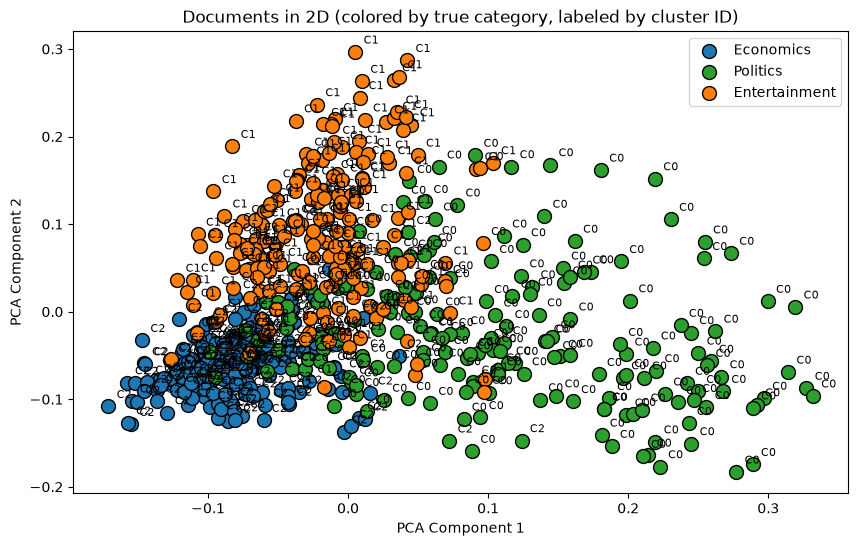

In [11]:
# visualization 

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X_tfidf.toarray())

plt.figure(figsize=(10, 6))
colors = {'Economics': 'tab:blue', 'Entertainment': 'tab:orange', 'Politics': 'tab:green'}

for category in df['true_category'].unique():
    mask = df['true_category'] == category
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=category,
                color=colors.get(category, 'gray'), s=100, edgecolor='black')

for i, row in df.iterrows():
    plt.annotate(f"C{row['cluster']}", (X_2d[i, 0], X_2d[i, 1]),
                 textcoords="offset points", xytext=(6, 6), fontsize=8)

plt.title("Documents in 2D (colored by true category, labeled by cluster ID)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

In [12]:

# mapping clusters to categories
def build_cluster_to_category_map(data_frame):
    mapping = {}
    for cluster_id in sorted(data_frame['cluster'].unique()):
        subset = data_frame[data_frame['cluster'] == cluster_id]
        majority_category = subset['true_category'].mode()[0]
        mapping[cluster_id] = majority_category
    return mapping

cluster_to_category = build_cluster_to_category_map(df)

print(f"Categorized groups: \n{cluster_to_category}\n")



Categorized groups: 
{np.int32(0): 'Politics', np.int32(1): 'Entertainment', np.int32(2): 'Economics'}



In [13]:
# mapping cluster 0,1,2 to its name
df['predicted_category'] = df['cluster'].map(cluster_to_category)


In [14]:
df.head()

,document,true_category,cluster,predicted_category
0,Legislators are debating a progressive wealth ...,Economics,2,Economics
1,Global leaders released a joint statement stro...,Politics,0,Politics
2,The massive national debate over strictly impl...,Politics,0,Politics
3,Rising energy costs are severely impacting the...,Economics,2,Economics
4,Corporate debt issuance shifted toward shorter...,Economics,2,Economics


In [15]:

# calculating overall accuracy
accuracy = (df['true_category'] == df['predicted_category']).mean()
print(f"Overall Clustering Accuracy: {accuracy:.2%}\n")

# showing classification report
print("Classification Report:\n")

print(classification_report(df['true_category'], df['predicted_category']))

Overall Clustering Accuracy: 93.83%

Classification Report:

               precision    recall  f1-score   support

    Economics       0.92      0.97      0.94       200
Entertainment       0.95      0.94      0.95       200
     Politics       0.94      0.91      0.92       200

     accuracy                           0.94       600
    macro avg       0.94      0.94      0.94       600
 weighted avg       0.94      0.94      0.94       600



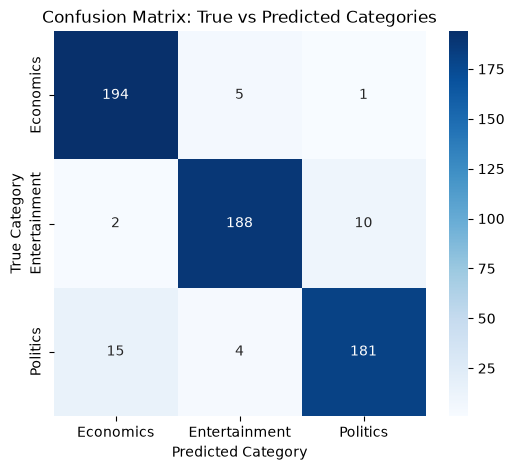

In [16]:
# evaluation

# plotting confusion matrix
categories_list = ['Economics', 'Entertainment', 'Politics']
cm_matrix = confusion_matrix(df['true_category'], df['predicted_category'], labels=categories_list)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=categories_list, yticklabels=categories_list)
plt.title("Confusion Matrix: True vs Predicted Categories")
plt.xlabel("Predicted Category")
plt.ylabel("True Category")
plt.show()

Saving for fastapi

In [17]:
# function to save JSON docs data
def save_docs(file_path, dict_clustered_docs): 
         
    # ensuring the target directory exists before saving
    os.makedirs(os.path.dirname(file_path), exist_ok=True)

    # writing the python dictionary list to the json file
    with open(file_path, "w", encoding="utf-8") as f:
        json.dump(dict_clustered_docs, f, indent=4)
        
        
    print(f"JSON file saved successfully in this path: {file_path}")

In [18]:
        
# converting the dataframe to a list of dictionaries       
dict_clustered_docs = df.to_dict(orient="records")
first_file_path_and_name = "../app/clustering_tasks/documents/all_docs.json"
second_file_path_and_name = "./data/all_docs.json"

for file_path in [first_file_path_and_name, second_file_path_and_name]:
    save_docs(file_path, dict_clustered_docs)


JSON file saved successfully in this path: ../app/clustering_tasks/documents/all_docs.json
JSON file saved successfully in this path: ./data/all_docs.json


Saving in DB

In [19]:
from pymongo import MongoClient


In [20]:
def launch_db(db_name, mongo_url):
    
        
    client = MongoClient(local_mongo_url)
    db = client[db_name]

    # for storing clustered data to 
    clustered_docs = db["clustered_docs"]

    print("Connected:", db.name, "| collections:", db.list_collection_names())
    
    return db, clustered_docs

In [21]:
db_name = "vertical_search_engine_cw"
local_mongo_url = "mongodb://localhost:27017"

# for local mongodb 
db, clustered_docs = launch_db(db_name, local_mongo_url)


# for cloud mongodb 
# db, clustered_docs = launch_db(db_name=os.getenv("CLOUD_DB_NAME"), mongo_url=os.getenv("CLOUD_MONGODB_URL"))


Connected: vertical_search_engine_cw | collections: ['crawl_log', 'doc_vectors', 'term_index', 'raw_pages_publications', 'raw_pages_profiles', 'clustered_docs']


In [22]:
print(f"\n{'=' * 20} Clustered data deleting and saving in DB {'=' * 20}\n")

# delete older clustered data
clustered_docs.delete_many({})
print("Deleted older clustered data successfully...")


# converting dataframe into dictionary for saving clustered data into Mongo DB
dict_clustered_docs = df.to_dict(orient="records")

# MongoDB collection in this project requires a unique url field for each document.
for index, record in enumerate(dict_clustered_docs):
    record["url"] = f"clustered-doc-{index}-{record['true_category']}-{record['cluster']}"

# storing document, true_category, cluster, and predicted_category in the DB
clustered_docs.insert_many(dict_clustered_docs)

print(f"\n{'=' * 20} Clustered data stored in the DB with {len(dict_clustered_docs)} length {'=' * 20}\n")



==================== Clustered data deleting and saving in DB ====================

Deleted older clustered data successfully...

==================== Clustered data stored in the DB with 600 length ====================



In [23]:
# # classifying the document using both the vectorizer and lsa pipeline
# def classify_document(new_text, vectorizer, lsa_pipeline, kmeans_model, cluster_to_category):
#     # transforming the text into tf-idf vectors
#     new_vec = vectorizer.transform([new_text])
    
#     # reducing dimensions using the fitted lsa pipeline
#     new_lsa = lsa_pipeline.transform(new_vec)

#     # finding the closest cluster centroid
#     predicted_cluster = kmeans_model.predict(new_lsa)[0]

#     # translating the cluster number into a category name
#     predicted_category = cluster_to_category[predicted_cluster]
    
#     return predicted_cluster, predicted_category


In [24]:
# classifying unseen text using vectorizer and lsa pipeline
def classify_unseen_text(text):
  text_vec = vectorizer.transform([text])
  text_lsa = lsa_pipeline.transform(text_vec)
  predicted_cluster = kmeans.predict(text_lsa)[0]
  predicted_label = cluster_to_category[predicted_cluster]
  return predicted_cluster, predicted_label

In [25]:

# testing unseen sample sentences
test_sentences = [
    (
        'The central bank lowered benchmark borrowing rates to stimulate real'
        ' estate demand.'
    ),
    (
        'The sci-fi blockbuster dominated the summer box office and won'
        ' multiple Academy Awards.'
    ),
    (
        'Parliament passed the controversial defense spending bill following a'
        ' heated legislative debate.'
    ),
]

print('UNSEEN TEXT INFERENCE TEST:')
print('-' * 60)
for sentence in test_sentences:
  cid, label = classify_unseen_text(sentence)
  print(f'Text  : "{sentence}"')
  print(f'Result: Cluster {cid} -> Category: {label}\n')


UNSEEN TEXT INFERENCE TEST:
------------------------------------------------------------
Text  : "The central bank lowered benchmark borrowing rates to stimulate real estate demand."
Result: Cluster 2 -> Category: Economics

Text  : "The sci-fi blockbuster dominated the summer box office and won multiple Academy Awards."
Result: Cluster 1 -> Category: Entertainment

Text  : "Parliament passed the controversial defense spending bill following a heated legislative debate."
Result: Cluster 0 -> Category: Politics



In [26]:
# TODO: user's query must be stored in the DB after clustering it

# # storing updated records in mongodb collection
# clustered_docs.insert_many(dict_clustered_docs)
# print(f'Successfully stored {len(dict_clustered_docs)} records into MongoDB!')

In [27]:

# prompting the user for input and classifying the text interactively
def interactive_classify():
    user_text = input("Enter a sentence to classify: ")
    print(f"{user_text}:\n")
    
    if not user_text.strip():
        print("No text entered.")
        return
        
    # passing the newly required lsa_pipeline into the function call
    cluster_id, category = classify_unseen_text(
        user_text
    )
    
    print(f"\nPredicted cluster: {cluster_id}")
    print(f"Predicted category: {category}")

In [28]:
interactive_classify()


Crude oil prices have seen renewed upward pressure past $91 a barrel following geopolitical developments in the Middle East:


Predicted cluster: 2
Predicted category: Economics


In [29]:
import joblib
import os

In [30]:

# defining the export directory path (saving in this path ==> ../app/clustering_tasks/pkl/)
export_dir = "../app/clustering_tasks/pkl/"

# exporting the trained tf-idf vectorizer
joblib.dump(vectorizer, os.path.join(export_dir, 'tfidf_vectorizer.pkl'))

# exporting the lsa dimensionality reduction pipeline
joblib.dump(lsa_pipeline, os.path.join(export_dir, 'lsa_pipeline.pkl'))

# exporting the trained k-means clustering model
joblib.dump(kmeans, os.path.join(export_dir, 'kmeans_model.pkl'))

# exporting the dictionary that maps cluster ids to category strings
joblib.dump(cluster_to_category, os.path.join(export_dir, 'cluster_to_category.pkl'))

print("All 4 model artifacts have been successfully exported to .pkl files!")

All 4 model artifacts have been successfully exported to .pkl files!


In [31]:
# loading the artifacts back from the disk to verify integrity
loaded_vectorizer = joblib.load(f'{export_dir}tfidf_vectorizer.pkl')
loaded_lsa = joblib.load(f'{export_dir}lsa_pipeline.pkl')
loaded_kmeans = joblib.load(f'{export_dir}kmeans_model.pkl')
loaded_mapping = joblib.load(f'{export_dir}cluster_to_category.pkl')

# testing the loaded model with a dummy sentence
test_text = "Nepal's stock market crashed today."
test_vec = loaded_vectorizer.transform([test_text])
test_lsa = loaded_lsa.transform(test_vec)
pred_cluster = loaded_kmeans.predict(test_lsa)[0]
pred_category = loaded_mapping[pred_cluster]

print(f"Test sentence predicted as: {pred_category} (Cluster {pred_cluster})")
print("Verification complete! The .pkl files are ready for FastAPI.")

Test sentence predicted as: Economics (Cluster 2)
Verification complete! The .pkl files are ready for FastAPI.
